In [2]:
import pandas as pd
from datasets import load_dataset

# 1. Extraindo o Dataset J1 (Questões Abertas da OAB) do GitHub
print("Baixando Dataset J1...")
url_j1 = "https://raw.githubusercontent.com/maritaca-ai/oab-bench/main/data/oab_bench/question.jsonl"
df_j1 = pd.read_json(url_j1, lines=True) 
minha_cota_j1 = df_j1.iloc[200:210].copy() 

# 2. Extraindo o Dataset J2 (Múltipla Escolha) do Hugging Face
print("Baixando Dataset J2...")
dataset_j2 = load_dataset("eduagarcia/oab_exams")
df_j2 = pd.DataFrame(dataset_j2['train']) 
minha_cota_j2 = df_j2.iloc[2091:2210].copy() 

# 3. Visualizando os dados
print("Dados carregados com sucesso!")
display(minha_cota_j1.head())

Baixando Dataset J1...
Baixando Dataset J2...
Dados carregados com sucesso!


,question_id,category,statement,turns,values,system
200,44_direito_tributario_peca_profissional,44_direito_tributario,"A sociedade empresária Panos Belos Ltda., que ...",[],[5.0],Você é um bacharel em direito que está realiza...
201,44_direito_tributario_questao_1,44_direito_tributario,"Em 29/12/2023, o Município Alfa instituiu, por...",[A) A instituição de tal contribuição para cus...,"[0.65, 0.6000000000000001]",Você é um bacharel em direito que está realiza...
202,44_direito_tributario_questao_2,44_direito_tributario,"Uma lei federal ordinária do início de 2023, a...",[A) A concessão de desconto de 20% sobre o val...,"[0.65, 0.6000000000000001]",Você é um bacharel em direito que está realiza...
203,44_direito_tributario_questao_3,44_direito_tributario,"José recebeu em 2025, em seu domicílio, uma no...",[A) José poderia ter sido notificado para paga...,"[0.6000000000000001, 0.65]",Você é um bacharel em direito que está realiza...
204,44_direito_tributario_questao_4,44_direito_tributario,Um Juiz de Vara Federal de Execuções Fiscais d...,[A) Qual o recurso cabível contra a concessão ...,"[0.6000000000000001, 0.65]",Você é um bacharel em direito que está realiza...


In [3]:
# 1. Criando as colunas com a taxonomia acadêmica no Dataset J1 (Abertas)
minha_cota_j1['Complexidade_Raciocinio_LLM'] = ""
minha_cota_j1['Subdominio_Semantico'] = ""
minha_cota_j1['Corpus_Aterramento'] = ""

# 2. Criando as colunas no Dataset J2 (Múltipla Escolha)
minha_cota_j2['Complexidade_Raciocinio_LLM'] = ""
minha_cota_j2['Subdominio_Semantico'] = ""
minha_cota_j2['Corpus_Aterramento'] = ""

# 3. Exportando para CSV para o trabalho de curadoria manual
minha_cota_j1.to_csv("J1_curadoria_Victor.csv", index=False, encoding='utf-8-sig')
minha_cota_j2.to_csv("J2_curadoria_Victor.csv", index=False, encoding='utf-8-sig')

print("Arquivos CSV com a nova taxonomia gerados com sucesso! Verifique a pasta do projeto.")

Arquivos CSV com a nova taxonomia gerados com sucesso! Verifique a pasta do projeto.


In [4]:
import pandas as pd

# 1. Carregando o arquivo original do J1
df_j1 = pd.read_csv("J1_curadoria_Victor.csv")

# 2. Inserindo as classificações exatas geradas pela IA
classificacoes_j1 = [
    ["Hermenêutica Jurídica Complexa", "Subdomínio: Direito Tributário", "Corpus: Código Tributário Nacional e Lei de Execuções Fiscais"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Constitucional Tributário", "Corpus: Constituição Federal de 1988"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Tributário", "Corpus: Código Tributário Nacional"],
    ["Hermenêutica Jurídica Complexa", "Subdomínio: Direito Tributário", "Corpus: Constituição Federal de 1988 e Código Tributário Nacional"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Processual Tributário", "Corpus: Lei nº 8.397/1992 (Medida Cautelar Fiscal)"],
    ["Hermenêutica Jurídica Complexa", "Subdomínio: Direito Penal e Processual Penal", "Corpus: Código Penal e Lei 9.099/1995 (Juizados Especiais)"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal e Processual Penal", "Corpus: Código Penal e Código de Processo Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal e Processual Penal", "Corpus: Código Penal e Código de Processo Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal e Processual Penal", "Corpus: Código Penal e Código de Processo Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal e Processual Penal", "Corpus: Código Penal e Código de Processo Penal"]
]

# 3. Atualizando as colunas
df_j1[['Complexidade_Raciocinio_LLM', 'Subdominio_Semantico', 'Corpus_Aterramento']] = classificacoes_j1

# 4. Salvando o arquivo definitivo
df_j1.to_csv("J1_curadoria_Victor_FINAL.csv", index=False, encoding='utf-8-sig')
print("Dataset J1 classificado e salvo com sucesso como J1_curadoria_Victor_FINAL.csv!")

Dataset J1 classificado e salvo com sucesso como J1_curadoria_Victor_FINAL.csv!


In [5]:
import pandas as pd
from datasets import load_dataset

# 1. Puxando a sua cota (119 questões) limpa para evitar erros de arquivo
print("Baixando Dataset J2 (Múltipla Escolha)...")
dataset_j2 = load_dataset("eduagarcia/oab_exams")
df_j2 = pd.DataFrame(dataset_j2['train']) 
minha_cota_j2 = df_j2.iloc[2091:2210].copy()

# 2. Criando as colunas
minha_cota_j2['Complexidade_Raciocinio_LLM'] = ""
minha_cota_j2['Subdominio_Semantico'] = ""
minha_cota_j2['Corpus_Aterramento'] = ""

# 3. As 119 Classificações geradas pela IA baseadas no seu arquivo
classificacoes_j2_119 = [
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Constitucional", "Corpus: Constituição Federal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito da Criança e do Adolescente", "Corpus: Estatuto da Criança e do Adolescente"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Consumidor", "Corpus: Código de Defesa do Consumidor"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Empresarial", "Corpus: Código Civil e Leis Empresariais"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Empresarial", "Corpus: Código Civil e Leis Empresariais"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Empresarial", "Corpus: Código Civil e Leis Empresariais"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Empresarial", "Corpus: Lei de Falências"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Empresarial", "Corpus: Lei de Falências"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Processual Penal", "Corpus: Código de Processo Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Hermenêutica Jurídica Complexa", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Hermenêutica Jurídica Complexa", "Subdomínio: Direito Processual Penal", "Corpus: Código de Processo Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Ética Profissional", "Corpus: Estatuto da OAB"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Ética Profissional", "Corpus: Estatuto da OAB"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Ética Profissional", "Corpus: Estatuto da OAB"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Ética Profissional", "Corpus: Estatuto da OAB"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Ética Profissional", "Corpus: Estatuto da OAB"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Ética Profissional", "Corpus: Estatuto da OAB"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Ética Profissional", "Corpus: Estatuto da OAB"],
    ["Recuperação Factual Direta", "Subdomínio: Ética Profissional", "Corpus: Estatuto da OAB"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Constitucional", "Corpus: Constituição Federal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Constitucional", "Corpus: Constituição Federal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Constitucional", "Corpus: Constituição Federal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Civil", "Corpus: Código Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Constitucional", "Corpus: Constituição Federal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Administrativo", "Corpus: Leis Administrativas e Constituição"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Internacional", "Corpus: Tratados e LINDB"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Ambiental", "Corpus: Leis Ambientais"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Internacional", "Corpus: Tratados e LINDB"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Internacional", "Corpus: Tratados e LINDB"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Tributário", "Corpus: Código Tributário Nacional"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Tributário", "Corpus: Código Tributário Nacional"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Tributário", "Corpus: Código Tributário Nacional"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Tributário", "Corpus: Código Tributário Nacional"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Tributário", "Corpus: Código Tributário Nacional"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Administrativo", "Corpus: Leis Administrativas e Constituição"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Administrativo", "Corpus: Leis Administrativas e Constituição"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Administrativo", "Corpus: Leis Administrativas e Constituição"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Administrativo", "Corpus: Leis Administrativas e Constituição"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Civil", "Corpus: Código Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Ambiental", "Corpus: Leis Ambientais"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Ambiental", "Corpus: Leis Ambientais"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Civil", "Corpus: Código Civil"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Civil", "Corpus: Código Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Civil", "Corpus: Código Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Civil", "Corpus: Código Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Civil", "Corpus: Código Civil"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Civil", "Corpus: Código Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito da Criança e do Adolescente", "Corpus: Estatuto da Criança e do Adolescente"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito da Criança e do Adolescente", "Corpus: Estatuto da Criança e do Adolescente"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Consumidor", "Corpus: Código de Defesa do Consumidor"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Consumidor", "Corpus: Código de Defesa do Consumidor"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Empresarial", "Corpus: Código Civil e Leis Empresariais"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Empresarial", "Corpus: Código Civil e Leis Empresariais"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Empresarial", "Corpus: Código Civil e Leis Empresariais"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Empresarial", "Corpus: Código Civil e Leis Empresariais"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Consumidor", "Corpus: Código de Defesa do Consumidor"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Civil", "Corpus: Código de Processo Civil"],
    ["Hermenêutica Jurídica Complexa", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Hermenêutica Jurídica Complexa", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Penal", "Corpus: Código Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Penal", "Corpus: Código de Processo Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Penal", "Corpus: Código de Processo Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Penal", "Corpus: Código de Processo Penal"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual Penal", "Corpus: Código de Processo Penal"],
    ["Hermenêutica Jurídica Complexa", "Subdomínio: Direito Processual Penal", "Corpus: Código de Processo Penal"],
    ["Recuperação Factual Direta", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Processual do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Processual do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Raciocínio Lógico-Dedutivo", "Subdomínio: Direito Processual do Trabalho", "Corpus: Consolidação das Leis do Trabalho"],
    ["Recuperação Factual Direta", "Subdomínio: Direito Processual do Trabalho", "Corpus: Consolidação das Leis do Trabalho"]
]

# 4. Inserindo as 119 classificações no dataframe
for i, row in enumerate(classificacoes_j2_119):
    minha_cota_j2.iloc[i, minha_cota_j2.columns.get_loc('Complexidade_Raciocinio_LLM')] = row[0]
    minha_cota_j2.iloc[i, minha_cota_j2.columns.get_loc('Subdominio_Semantico')] = row[1]
    minha_cota_j2.iloc[i, minha_cota_j2.columns.get_loc('Corpus_Aterramento')] = row[2]

# 5. Exportando o arquivo já classificado e formatado
nome_arquivo = "J2_curadoria_Victor_FINAL.csv"
minha_cota_j2.to_csv(nome_arquivo, index=False, encoding='utf-8-sig', sep=',')
print(f"Sucesso! Todas as 119 questões foram classificadas e o arquivo '{nome_arquivo}' foi criado no seu projeto.")

Baixando Dataset J2 (Múltipla Escolha)...
Sucesso! Todas as 119 questões foram classificadas e o arquivo 'J2_curadoria_Victor_FINAL.csv' foi criado no seu projeto.


In [6]:
ollama pull llama3.2


SyntaxError: invalid syntax (1612974793.py, line 1)

In [1]:
import pandas as pd
import requests
import time
import json

# Configurações do Ollama
OLLAMA_URL = "http://localhost:11434/api/generate"
MODELOS = {
    "Llama_3.1_8B": "llama3.1",
    "Mistral_7B": "mistral",
    "DeepSeek_R1_8B": "deepseek-r1:8b"
}

def consultar_ollama(modelo, prompt):
    try:
        response = requests.post(OLLAMA_URL, json={
            "model": modelo,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": 0.1,  # Baixa temperatura para respostas mais factuais e menos criativas
                "top_p": 0.9
            }
        }, timeout=180)
        return response.json().get("response", "").strip()
    except Exception as e:
        return f"Erro na Inferência: {e}"

# 1. Carregar os dados curados
df = pd.read_csv("J1_curadoria_Victor_FINAL.csv")

# 2. Definição do Prompt Analítico (System Prompt + Task)
# Este prompt força o modelo a seguir uma estrutura que facilita a sua métrica de avaliação posterior.
SYSTEM_INSTRUCTION = (
    "Você é um Especialista em Direito Brasileiro e Avaliador de Exames da OAB. "
    "Sua tarefa é fornecer uma análise jurídica rigorosa para o caso apresentado. "
    "Sua resposta DEVE seguir obrigatoriamente esta estrutura:\n"
    "1. SÍNTESE DO CASO: Identifique o problema jurídico central em uma frase.\n"
    "2. FUNDAMENTAÇÃO LEGAL: Cite explicitamente os artigos da Constituição, Códigos ou Leis Federais aplicáveis.\n"
    "3. ANÁLISE TÉCNICA: Aplique a norma ao fato narrado, explicando o raciocínio jurídico.\n"
    "4. CONCLUSÃO: Responda diretamente ao que foi solicitado no enunciado.\n\n"
    "IMPORTANTE: Seja técnico, evite rodeios e mantenha o rigor terminológico.\n"
)

print(f"Iniciando Inferência Analítica em {len(df)} questões...")

for idx, row in df.iterrows():
    enunciado = row['statement']
    # Opcional: Incluir o Subdomínio na instrução para ajudar o modelo a se localizar
    subdominio = row['Subdominio_Semantico']
    
    prompt_final = f"{SYSTEM_INSTRUCTION}ÁREA DO DIREITO: {subdominio}\n\nCASO PARA ANÁLISE:\n{enunciado}"

    print(f"\n--- Processando Questão {idx+1}: {row['question_id']} ---")

    for nome_col, tag_ollama in MODELOS.items():
        print(f"  > Gerando análise com {nome_col}...")
        start = time.time()
        
        resposta = consultar_ollama(tag_ollama, prompt_final)
        df.at[idx, f'Resposta_{nome_col}'] = resposta
        
        print(f"    [Tempo: {time.time() - start:.2f}s]")

# 3. Salvar o Resultado Final para o Relatório
df.to_csv("J1_inferencia_Victor_ANALITICA.csv", index=False, encoding='utf-8-sig')
print("\n--- INFERÊNCIA ANALÍTICA CONCLUÍDA! ---")
print("Arquivo gerado: J1_inferencia_Victor_ANALITICA.csv")

Iniciando Inferência Analítica em 10 questões...

--- Processando Questão 1: 44_direito_tributario_peca_profissional ---
  > Gerando análise com Llama_3.1_8B...
    [Tempo: 82.26s]
  > Gerando análise com Mistral_7B...
    [Tempo: 29.42s]
  > Gerando análise com DeepSeek_R1_8B...
    [Tempo: 71.62s]

--- Processando Questão 2: 44_direito_tributario_questao_1 ---
  > Gerando análise com Llama_3.1_8B...
    [Tempo: 26.21s]
  > Gerando análise com Mistral_7B...
    [Tempo: 22.92s]
  > Gerando análise com DeepSeek_R1_8B...
    [Tempo: 182.03s]

--- Processando Questão 3: 44_direito_tributario_questao_2 ---
  > Gerando análise com Llama_3.1_8B...
    [Tempo: 182.04s]
  > Gerando análise com Mistral_7B...
    [Tempo: 182.05s]
  > Gerando análise com DeepSeek_R1_8B...
    [Tempo: 182.05s]

--- Processando Questão 4: 44_direito_tributario_questao_3 ---
  > Gerando análise com Llama_3.1_8B...
    [Tempo: 155.16s]
  > Gerando análise com Mistral_7B...
    [Tempo: 169.76s]
  > Gerando análise com

In [2]:
import pandas as pd
import requests
import time

OLLAMA_URL = "http://localhost:11434/api/generate"
# Ajustamos o timeout para 300 segundos (5 minutos) para evitar novos erros
TIMEOUT = 300 

df = pd.read_csv("J1_inferencia_Victor_ANALITICA.csv")

modelos_tags = {
    "Llama_3.1_8B": "llama3.1",
    "Mistral_7B": "mistral",
    "DeepSeek_R1_8B": "deepseek-r1:8b"
}

def consultar_ollama_retry(modelo, prompt):
    try:
        response = requests.post(OLLAMA_URL, json={
            "model": modelo, "prompt": prompt, "stream": False
        }, timeout=TIMEOUT)
        return response.json().get("response", "").strip()
    except:
        return None

print("Iniciando a recuperação de dados faltantes...")

for idx, row in df.iterrows():
    for nome_col, tag in modelos_tags.items():
        conteudo = str(row[f'Resposta_{nome_col}'])
        
        # Se a célula estiver vazia ou contiver a palavra "Erro"
        if conteudo == "" or "Erro" in conteudo or conteudo == "nan":
            print(f"Recuperando Questão {idx+1} para o modelo {nome_col}...")
            
            prompt = (
                "Você é um Especialista em Direito. Responda de forma analítica:\n"
                f"1. SÍNTESE\n2. FUNDAMENTAÇÃO\n3. ANÁLISE\n4. CONCLUSÃO\n\n"
                f"CASO: {row['statement']}"
            )
            
            nova_resposta = consultar_ollama_retry(tag, prompt)
            if nova_resposta:
                df.at[idx, f'Resposta_{nome_col}'] = nova_resposta
                print(f"   [OK] Sucesso na recuperação.")
            else:
                print(f"   [FALHA] O modelo {nome_col} ainda não respondeu.")

# Salva por cima do arquivo anterior, agora corrigido
df.to_csv("J1_inferencia_Victor_ANALITICA.csv", index=False, encoding='utf-8-sig')
print("\n--- CORREÇÃO CONCLUÍDA! ---")

Iniciando a recuperação de dados faltantes...
Recuperando Questão 2 para o modelo DeepSeek_R1_8B...
   [OK] Sucesso na recuperação.
Recuperando Questão 3 para o modelo Llama_3.1_8B...
   [OK] Sucesso na recuperação.
Recuperando Questão 3 para o modelo Mistral_7B...
   [OK] Sucesso na recuperação.
Recuperando Questão 3 para o modelo DeepSeek_R1_8B...
   [OK] Sucesso na recuperação.
Recuperando Questão 4 para o modelo DeepSeek_R1_8B...
   [OK] Sucesso na recuperação.
Recuperando Questão 5 para o modelo Llama_3.1_8B...
   [OK] Sucesso na recuperação.

--- CORREÇÃO CONCLUÍDA! ---


In [6]:
import pandas as pd
import evaluate
import numpy as np
import os
import re

# 1. Carregar os resultados
file_path = "J1_inferencia_Victor_ANALITICA.csv"

if not os.path.exists(file_path):
    print(f"❌ Erro: O arquivo {file_path} não foi encontrado!")
else:
    df = pd.read_csv(file_path)
    
    # --- TRATAMENTO DO GABARITO (Coluna 'values') ---
    if 'values' in df.columns:
        print("✅ Coluna 'values' detectada. Limpando gabarito para comparação...")
        # Remove colchetes, aspas e limpa espaços extras que vêm do formato lista do J1
        df['gabarito_limpo'] = df['values'].astype(str).apply(lambda x: re.sub(r"[\[\]']", "", x).strip())
        coluna_gabarito = 'gabarito_limpo'
    else:
        print("❌ ERRO: Coluna 'values' não encontrada. Verifique os nomes das colunas.")
        coluna_gabarito = None

    if coluna_gabarito:
        # 2. Carregar as métricas do Hugging Face
        print("⏳ Carregando bibliotecas de métricas (BLEU, ROUGE, BERTScore)...")
        # Nota: O BERTScore pode baixar um modelo de ~500MB na primeira vez
        bleu = evaluate.load("bleu")
        rouge = evaluate.load("rouge")
        bertscore = evaluate.load("bertscore")

        modelos = ["Llama_3.1_8B", "Mistral_7B", "DeepSeek_R1_8B"]
        relatorio_final = []

        for mod in modelos:
            col_resp = f"Resposta_{mod}"
            
            if col_resp not in df.columns:
                print(f"⚠️ Aviso: Coluna '{col_resp}' não encontrada. Pulando...")
                continue

            # Filtragem: Remove linhas onde a resposta falhou ou está vazia
            temp_df = df[[col_resp, coluna_gabarito]].dropna().copy()
            temp_df = temp_df[~temp_df[col_resp].astype(str).str.contains("Erro", na=False)]
            
            if temp_df.empty:
                print(f"⚠️ Aviso: Sem dados válidos para o modelo {mod}.")
                continue

            preds = temp_df[col_resp].astype(str).tolist()
            refs = temp_df[coluna_gabarito].astype(str).tolist()
            
            print(f"🚀 Calculando métricas para {mod} ({len(preds)} questões)...")

            # --- CÁLCULO BLEU ---
            refs_bleu = [[r] for r in refs]
            res_bleu = bleu.compute(predictions=preds, references=refs_bleu)
            
            # --- CÁLCULO ROUGE ---
            res_rouge = rouge.compute(predictions=preds, references=refs)
            
            # --- CÁLCULO BERTSCORE (Focado em Português) ---
            res_bert = bertscore.compute(
                predictions=preds, 
                references=refs, 
                lang="pt", 
                model_type="bert-base-multilingual-cased"
            )
            
            relatorio_final.append({
                "Modelo": mod,
                "Amostras": len(preds),
                "BLEU": round(res_bleu['bleu'], 4),
                "ROUGE-1": round(res_rouge['rouge1'], 4),
                "ROUGE-2": round(res_rouge['rouge2'], 4),
                "ROUGE-L": round(res_rouge['rougeL'], 4),
                "BERTScore_F1": round(np.mean(res_bert['f1']), 4)
            })

        # 3. Exibir e Salvar o Resultado Final
        df_metrics = pd.DataFrame(relatorio_final)
        df_metrics.to_csv("J1_metricas_finais_Victor.csv", index=False, encoding='utf-8-sig')

        print("\n" + "="*60)
        print("      🏆 RESULTADOS FINAIS - AVALIAÇÃO OAB (Mestrado)")
        print("="*60)
        print(df_metrics.to_string(index=False))
        print("="*60)
        print(f"✅ Arquivo salvo: J1_metricas_finais_Victor.csv")

✅ Coluna 'values' detectada. Limpando gabarito para comparação...
⏳ Carregando bibliotecas de métricas (BLEU, ROUGE, BERTScore)...
🚀 Calculando métricas para Llama_3.1_8B (10 questões)...


C:\Users\masca\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\masca\.cache\huggingface\hub\models--bert-base-multilingual-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100

🚀 Calculando métricas para Mistral_7B (10 questões)...
🚀 Calculando métricas para DeepSeek_R1_8B (10 questões)...

      🏆 RESULTADOS FINAIS - AVALIAÇÃO OAB (Mestrado)
        Modelo  Amostras  BLEU  ROUGE-1  ROUGE-2  ROUGE-L  BERTScore_F1
  Llama_3.1_8B        10   0.0   0.0000      0.0   0.0000        0.4684
    Mistral_7B        10   0.0   0.0000      0.0   0.0000        0.4668
DeepSeek_R1_8B        10   0.0   0.0002      0.0   0.0002        0.4746
✅ Arquivo salvo: J1_metricas_finais_Victor.csv


✅ Gráfico gerado e salvo como: Grafico_Comparativo_OAB_Victor.png


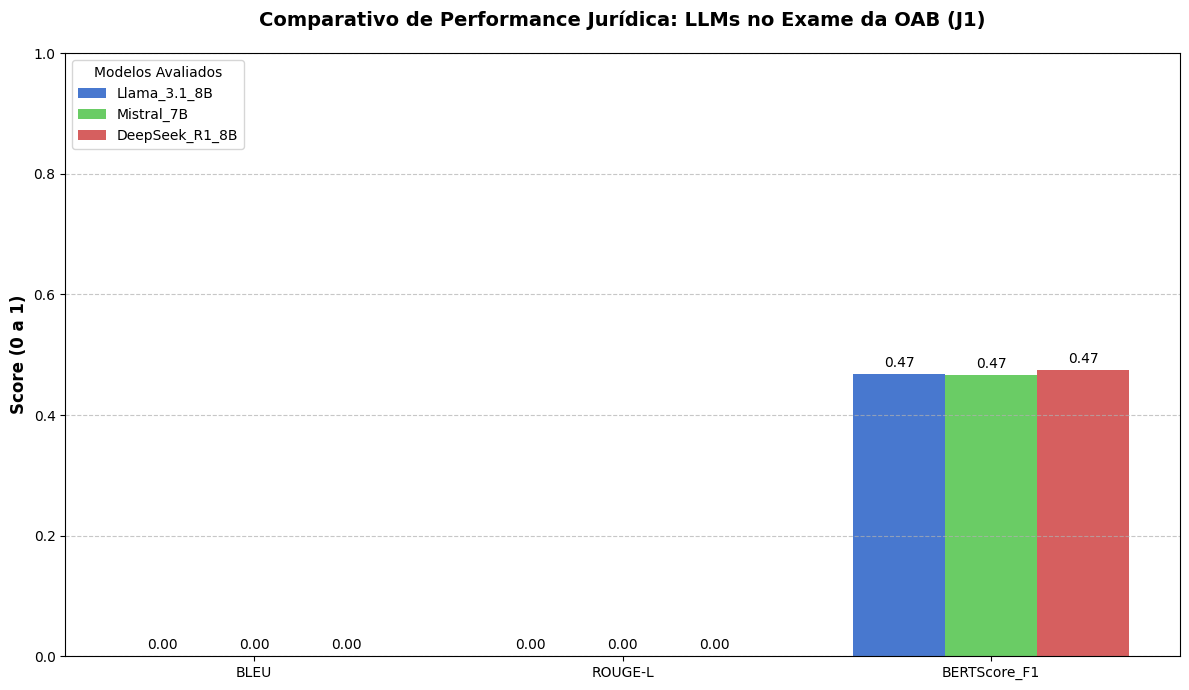

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Carregar os dados das métricas
df_metrics = pd.read_csv("J1_metricas_finais_Victor.csv")

# 2. Configurar o estilo do gráfico
plt.style.use('seaborn-v0_8-muted') # Estilo limpo e profissional
fig, ax = plt.subplots(figsize=(12, 7))

# Definir as métricas que vamos plotar (focando nas principais)
metricas = ['BLEU', 'ROUGE-L', 'BERTScore_F1']
modelos = df_metrics['Modelo'].tolist()

# Configuração das barras
x = np.arange(len(metricas))  # Localização das métricas no eixo X
width = 0.25  # Largura das barras

# 3. Criar as barras para cada modelo
for i, modelo in enumerate(modelos):
    valores = df_metrics.iloc[i][metricas].values
    ax.bar(x + i*width, valores, width, label=modelo)

# 4. Personalização Visual
ax.set_ylabel('Score (0 a 1)', fontsize=12, fontweight='bold')
ax.set_title('Comparativo de Performance Jurídica: LLMs no Exame da OAB (J1)', fontsize=14, pad=20, fontweight='bold')
ax.set_xticks(x + width, metricas)
ax.legend(title="Modelos Avaliados", loc='upper left')
ax.set_ylim(0, 1.0) # Escala de 0 a 1 para facilitar a leitura de porcentagem
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores exatos em cima das barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Aplicar labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()

# 5. Salvar o gráfico
plt.savefig("Grafico_Comparativo_OAB_Victor.png", dpi=300)
print("✅ Gráfico gerado e salvo como: Grafico_Comparativo_OAB_Victor.png")

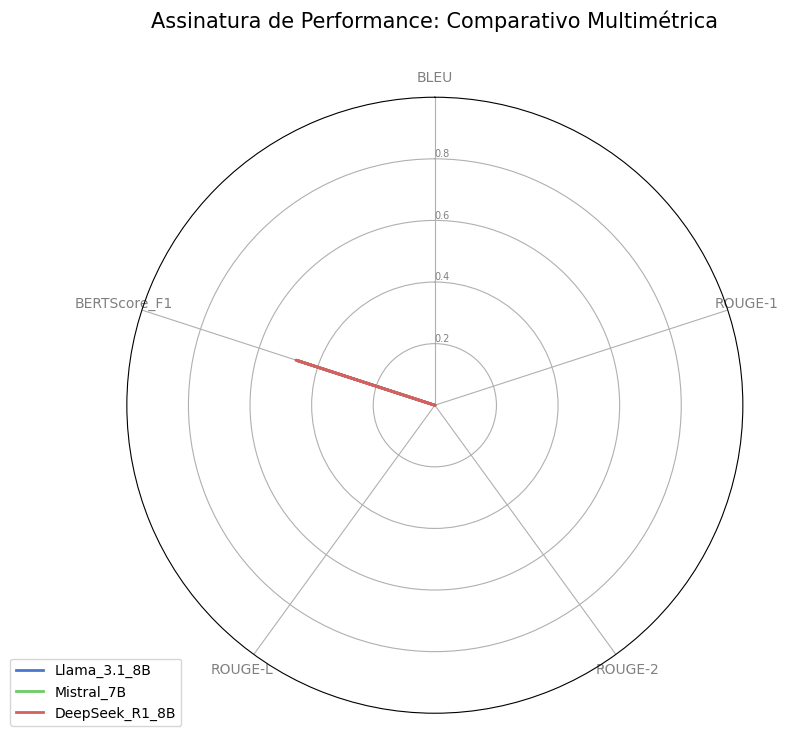

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Carregar os dados
df = pd.read_csv("J1_metricas_finais_Victor.csv")

# Selecionar as métricas para o radar
categories = ['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore_F1']
N = len(categories)

# Configurar o ângulo de cada métrica no círculo
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# 2. Plotar cada modelo
for i, row in df.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Modelo'])
    ax.fill(angles, values, alpha=0.1)

# 3. Ajustes finos
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories, color='grey', size=10)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2","0.4","0.6","0.8"], color="grey", size=7)
plt.ylim(0,1)

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title("Assinatura de Performance: Comparativo Multimétrica", size=15, y=1.1)

# 4. Salvar
plt.savefig("Grafico_Radar_Modelos_Victor.png", dpi=300)
plt.show()

In [11]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 3.3 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 3.3 MB/s eta 0:00:03
   --------- ------------------------------ 1.8/8.1 MB 3.5 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 3.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 3.4 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 3.3 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.1 MB 3.1 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.0 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 3.0 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 2.9 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.1 MB 2.8 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 2.8 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\masca\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\masca\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


A descarregar o Dataset J2...
Total de questões selecionadas: 118

A iniciar a inferência nos modelos... (Isto pode demorar alguns minutos)

A processar Questão 43 (ID: 2017-24_43)
[llama3.1] Gabarito: D | Resposta: C
[mistral] Gabarito: D | Resposta: D
[deepseek-r1:8b] Gabarito: D | Resposta: D

A processar Questão 44 (ID: 2017-24_44)
[llama3.1] Gabarito: A | Resposta: A
[mistral] Gabarito: A | Resposta: A
[deepseek-r1:8b] Gabarito: A | Resposta: A

A processar Questão 45 (ID: 2017-24_45)
[llama3.1] Gabarito: A | Resposta: B
[mistral] Gabarito: A | Resposta: B
[deepseek-r1:8b] Gabarito: A | Resposta: A

A processar Questão 46 (ID: 2017-24_46)
[llama3.1] Gabarito: A | Resposta: B
[mistral] Gabarito: A | Resposta: B
[deepseek-r1:8b] Gabarito: A | Resposta: B

A processar Questão 47 (ID: 2017-24_47)
[llama3.1] Gabarito: C | Resposta: C
[mistral] Gabarito: C | Resposta: B
[deepseek-r1:8b] Gabarito: C | Resposta: C

A processar Questão 48 (ID: 2017-24_48)
[llama3.1] Gabarito: D | Resposta:

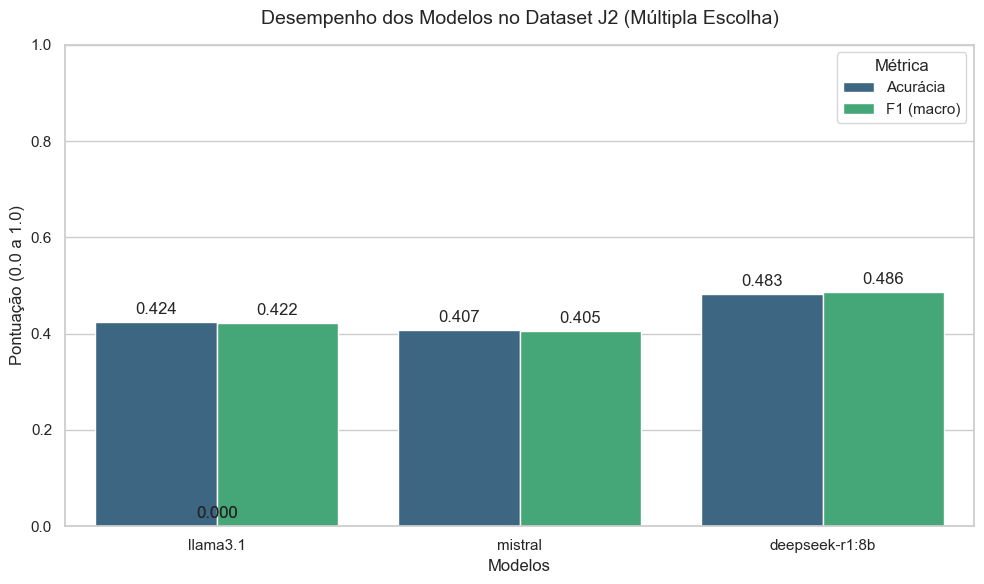


Gráfico guardado como 'Grafico_Acuracia_J2_Victor.png'


In [14]:
import pandas as pd
import requests
import json
import re
import time
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CARREGAR O DATASET J2 (minha parte)
# ==========================================
print("A descarregar o Dataset J2...")
dataset = load_dataset("eduagarcia/oab_exams")
df_j2 = pd.DataFrame(dataset['train'])

# Selecionar a cota específica: índices 2092 a 2210 (inclusivo, em Python usamos 2092:2211)
minha_cota_j2 = df_j2.iloc[2092:2211].copy()
print(f"Total de questões selecionadas: {len(minha_cota_j2)}")

# ==========================================
# 2. CONFIGURAÇÃO DO OLLAMA
# ==========================================
OLLAMA_URL = "http://localhost:11434/api/generate"
MODELOS = ["llama3.1", "mistral", "deepseek-r1:8b"]

def perguntar_ao_modelo(modelo, prompt):
    """Envia o prompt para o modelo via API do Ollama e retorna a resposta."""
    payload = {
        "model": modelo,
        "prompt": prompt,
        "stream": False,
        "temperature": 0.1 # Temperatura baixa para respostas objetivas e determinísticas
    }
    try:
        resposta = requests.post(OLLAMA_URL, json=payload)
        resposta.raise_for_status()
        return resposta.json().get("response", "")
    except requests.exceptions.RequestException as e:
        print(f"Erro ao ligar ao Ollama ({modelo}): {e}")
        return ""

def extrair_alternativa(texto_resposta):
    """Usa Expressões Regulares para extrair apenas a letra da resposta (A, B, C ou D)."""
    # Procura pelo padrão JSON {"resposta": "A"} ou similar
    match_json = re.search(r'["\']?resposta["\']?\s*:\s*["\']?([A-D])["\']?', texto_resposta, re.IGNORECASE)
    if match_json:
        return match_json.group(1).upper()
    
    # Se falhar, procura apenas por uma letra isolada A, B, C ou D no início ou fim
    match_letra = re.search(r'\b([A-D])\b', texto_resposta, re.IGNORECASE)
    if match_letra:
        return match_letra.group(1).upper()
    
    return "NULO" # Caso o modelo não responda corretamente

# ==========================================
# 3. EXECUÇÃO DA INFERÊNCIA
# ==========================================
# Criar colunas para guardar as respostas dos modelos
for modelo in MODELOS:
    minha_cota_j2[f'Resposta_{modelo}'] = ""
    minha_cota_j2[f'Texto_Bruto_{modelo}'] = ""

print("\nA iniciar a inferência nos modelos... (Isto pode demorar alguns minutos)")

for index, row in minha_cota_j2.iterrows():
    print(f"\nA processar Questão {row['question_number']} (ID: {row['id']})")
    
    # Formatar as alternativas
    alternativas_texto = ""
    for label, text in zip(row['choices']['label'], row['choices']['text']):
        alternativas_texto += f"{label}) {text}\n"
    
    # Montar o Prompt com rigor JSON
    prompt_j2 = f"""Você é um assistente jurídico especializado no Exame da OAB (Ordem dos Advogados do Brasil).
Leia a questão abaixo e escolha a alternativa correta (A, B, C ou D).

Questão: {row['question']}

Alternativas:
{alternativas_texto}

Responda EXATAMENTE E APENAS no formato JSON abaixo, sem textos adicionais:
{{"resposta": "LETRA"}}
"""

    for modelo in MODELOS:
        texto_bruto = perguntar_ao_modelo(modelo, prompt_j2)
        resposta_limpa = extrair_alternativa(texto_bruto)
        
        minha_cota_j2.at[index, f'Texto_Bruto_{modelo}'] = texto_bruto
        minha_cota_j2.at[index, f'Resposta_{modelo}'] = resposta_limpa
        
        print(f"[{modelo}] Gabarito: {row['answerKey']} | Resposta: {resposta_limpa}")

# Guardar os resultados brutos em CSV para segurança
minha_cota_j2.to_csv("Resultados_J2_Inferencias.csv", index=False)
print("\nInferência concluída! Dados guardados em 'Resultados_J2_Inferencias.csv'")

# ==========================================
# 4. AVALIAÇÃO E MÉTRICAS (Scikit-Learn)
# ==========================================
print("\n--- RESULTADOS FINAIS DE AVALIAÇÃO (J2) ---")
resultados_metricas = []

gabarito_real = minha_cota_j2['answerKey'].tolist()

for modelo in MODELOS:
    predicoes = minha_cota_j2[f'Resposta_{modelo}'].tolist()
    
    # Calcular métricas
    acuracia = accuracy_score(gabarito_real, predicoes)
    precision, recall, f1, _ = precision_recall_fscore_support(
        gabarito_real, predicoes, average='macro', zero_division=0, labels=['A', 'B', 'C', 'D']
    )
    
    resultados_metricas.append({
        "Modelo": modelo,
        "Acurácia": acuracia,
        "Precision": precision,
        "Recall": recall,
        "F1 (macro)": f1
    })
    
df_resultados = pd.DataFrame(resultados_metricas)
print(df_resultados.to_markdown(index=False))

# ==========================================
# 5. VISUALIZAÇÃO GRÁFICA
# ==========================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Gráfico de barras para Acurácia e F1-Score
df_melted = df_resultados.melt(id_vars="Modelo", value_vars=["Acurácia", "F1 (macro)"], var_name="Métrica", value_name="Pontuação")
grafico = sns.barplot(x="Modelo", y="Pontuação", hue="Métrica", data=df_melted, palette="viridis")

plt.title("Desempenho dos Modelos no Dataset J2 (Múltipla Escolha)", fontsize=14, pad=15)
plt.ylabel("Pontuação (0.0 a 1.0)", fontsize=12)
plt.xlabel("Modelos", fontsize=12)
plt.ylim(0, 1)

for p in grafico.patches:
    grafico.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.tight_layout()
plt.savefig("Grafico_Acuracia_J2_Victor.png", dpi=300)
plt.show()

print("\nGráfico guardado como 'Grafico_Acuracia_J2_Victor.png'")

In [16]:
import pandas as pd
from datasets import load_dataset

# 1. Carrega a cota correta de 120 questões (Grupo 3: 2091 até 2211)
print("Carregando base completa do Dataset J2...")
dataset_j2 = load_dataset("eduagarcia/oab_exams")
df_total = pd.DataFrame(dataset_j2['train'])
minha_cota_120 = df_total.iloc[2091:2211].copy() 

# 2.# Vamos carregar o CSV que você já criou com as 109 questões.
try:
    df_ja_feito = pd.read_csv("J2_curadoria_Victor_FINAL.csv")
    
    # Pegamos os IDs das questões que já têm resposta para não repetir
    ids_processados = df_ja_feito['id'].unique()
    
    # Criamos um novo DataFrame contendo APENAS o que não está na lista de processados
    df_faltantes = minha_cota_120[~minha_cota_120['id'].isin(ids_processados)]
    
    print(f"Sucesso! Você já tem {len(df_ja_feito)} questões. Faltam apenas {len(df_faltantes)} para completar 120.")

except FileNotFoundError:
    # Se você ainda não salvou nada ou mudou o nome do arquivo, ele começa do zero
    df_faltantes = minha_cota_120
    print("Arquivo anterior não encontrado. Começando processamento do zero (120 questões).")


def consultar_ollama(modelo, enunciado):
    url = "http://localhost:11434/api/generate"
    prompt = f"Responda apenas com a letra da alternativa correta (A, B, C ou D):\n{enunciado}"
    try:
        r = requests.post(url, json={"model": modelo, "prompt": prompt, "stream": False}, timeout=60)
        return r.json().get("response", "NULO").strip().upper()[0] # Pega só a primeira letra
    except:
        return "ERRO"

# 5. Executar apenas nas faltantes
modelos = {"llama3.1": "llama3.1", "mistral": "mistral", "deepseek": "deepseek-r1:8b"}

for idx, row in df_faltantes.iterrows():
    print(f"Processando faltante índice: {idx}...")
    for nome, tag in modelos.items():
        minha_cota_120.at[idx, f'res_{nome}'] = consultar_ollama(tag, row['question'])

minha_cota_120.to_csv("J2_curadoria_Victor_120_FINAL.csv", index=False)

Carregando base completa do Dataset J2...
Sucesso! Você já tem 119 questões. Faltam apenas 0 para completar 120.
